Saving motion_blur.jpeg to motion_blur (11).jpeg
Loaded: motion_blur (11).jpeg
Image size: (1024, 768)


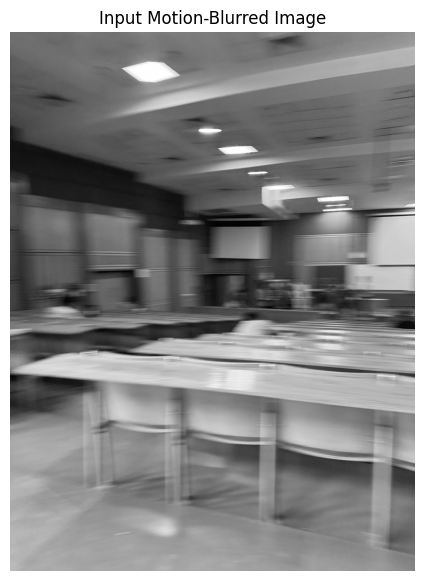

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import os

# Upload image
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Loaded:", filename)

# Read image
img = Image.open(filename).convert("L")

# Resize so long axis = 1024 pixels
max_dim = 1024
scale = max_dim / max(img.size)

if scale < 1:
    new_size = (round(img.size[0] * scale),
                round(img.size[1] * scale))
    img = img.resize(new_size, Image.Resampling.LANCZOS)

f = np.asarray(img, dtype=np.float64) / 255.0

print("Image size:", f.shape)

plt.figure(figsize=(10, 7))
plt.imshow(f, cmap="gray")
plt.title("Input Motion-Blurred Image")
plt.axis("off")
plt.show()

In [98]:
# ---------------------------------------------------------
# ESTIMATED MOTION BLUR
# ---------------------------------------------------------

# Estimated horizontal blur length in pixels
a = 30.0
b = 0.0

print(f"Estimated blur vector: (a, b) = ({a}, {b}) pixels")


# ---------------------------------------------------------
# FREQUENCY GRID
# ---------------------------------------------------------

M, N = f.shape

# u = horizontal frequency
# v = vertical frequency
u = np.fft.fftfreq(N)
v = np.fft.fftfreq(M)

U, V = np.meshgrid(u, v)


# ---------------------------------------------------------
# MOTION BLUR TRANSFER FUNCTION
#
# H(u,v) = exp[-i*pi*(a*u+b*v)] sinc(a*u+b*v)
#
# numpy.sinc(x) = sin(pi*x)/(pi*x)
# ---------------------------------------------------------

z = a * U + b * V

H = np.exp(-1j * np.pi * z) * np.sinc(z)

H_mag = np.abs(H)

print("H shape:", H.shape)
print("Maximum |H|:", H_mag.max())
print("Minimum |H|:", H_mag.min())

Estimated blur vector: (a, b) = (30.0, 0.0) pixels
H shape: (1024, 768)
Maximum |H|: 1.0
Minimum |H|: 3.898171832519376e-17


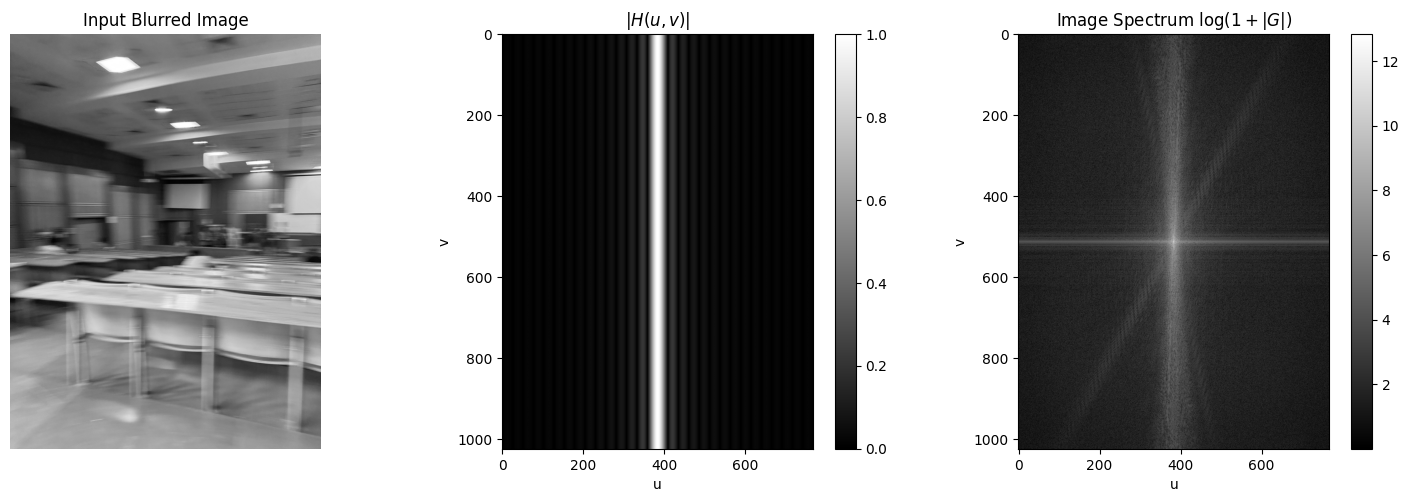

In [99]:
# Fourier transform of blurred image
F_blurred = np.fft.fft2(f)
F_blurred_shifted = np.fft.fftshift(F_blurred)

# Log spectrum for visualization
image_spectrum = np.log1p(np.abs(F_blurred_shifted))

# Shift H only for visualization
H_mag_shifted = np.fft.fftshift(H_mag)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(f, cmap="gray")
plt.title("Input Blurred Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(H_mag_shifted, cmap="gray")
plt.title(r"$|H(u,v)|$")
plt.xlabel("u")
plt.ylabel("v")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(image_spectrum, cmap="gray")
plt.title(r"Image Spectrum $\log(1+|G|)$")
plt.xlabel("u")
plt.ylabel("v")
plt.colorbar()

plt.tight_layout()
plt.show()

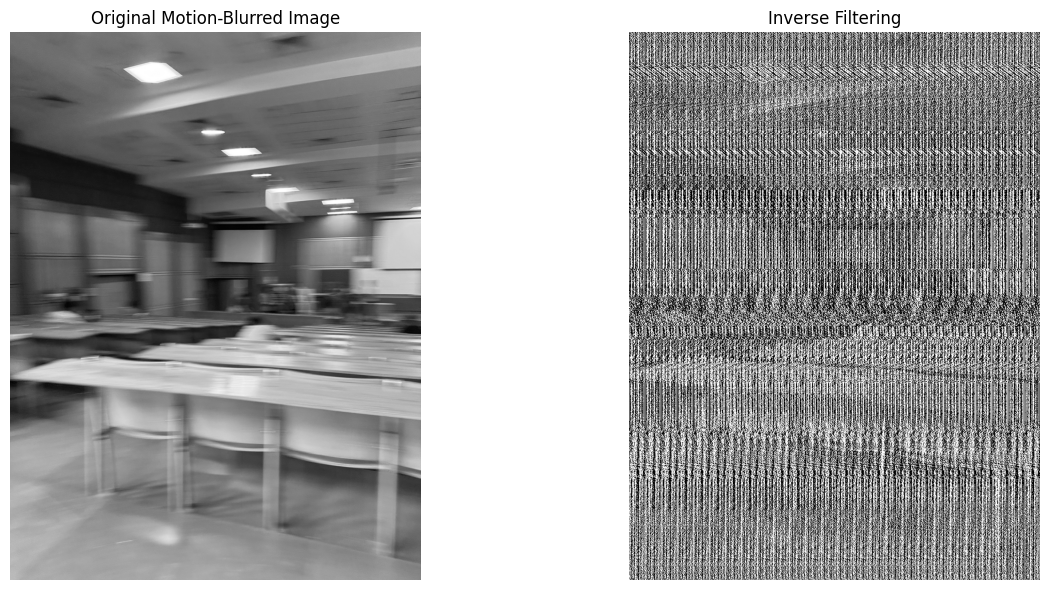

In [100]:
# ---------------------------------------------------------
# INVERSE FILTERING
# ---------------------------------------------------------

G = np.fft.fft2(f)

# Avoid division by values extremely close to zero
epsilon = 1e-3

H_safe = H.copy()
H_safe[np.abs(H_safe) < epsilon] = epsilon

# Inverse filter
F_inverse = G / H_safe

# Back to spatial domain
f_inverse = np.real(np.fft.ifft2(F_inverse))

# Clip for display
f_inverse_display = np.clip(f_inverse, 0, 1)


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(f, cmap="gray")
plt.title("Original Motion-Blurred Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(f_inverse_display, cmap="gray")
plt.title("Inverse Filtering")
plt.axis("off")

plt.tight_layout()
plt.show()

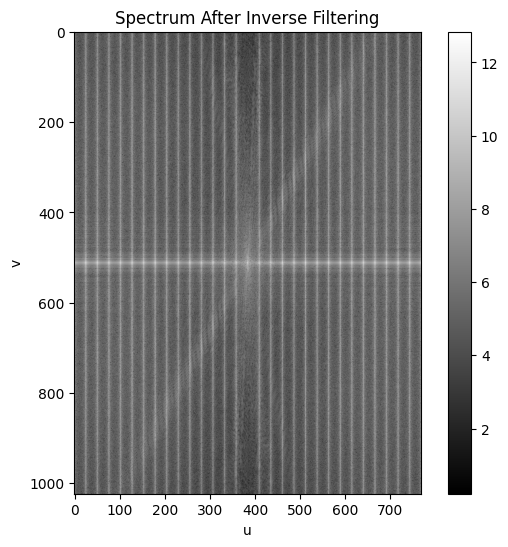

In [101]:
inverse_spectrum = np.log1p(
    np.abs(np.fft.fftshift(F_inverse))
)

plt.figure(figsize=(7, 6))
plt.imshow(inverse_spectrum, cmap="gray")
plt.title("Spectrum After Inverse Filtering")
plt.xlabel("u")
plt.ylabel("v")
plt.colorbar()
plt.show()

In [102]:
def wiener_deconvolution(G, H, K):

    # Wiener filter
    F_hat = (np.conj(H) * G) / (np.abs(H)**2 + K)

    # Convert back to spatial domain
    result = np.real(np.fft.ifft2(F_hat))

    # Remove numerical problems
    result = np.nan_to_num(
        result,
        nan=0.0,
        posinf=1.0,
        neginf=0.0
    )

    # Keep image intensities in [0,1]
    result = np.clip(result, 0, 1)

    return result

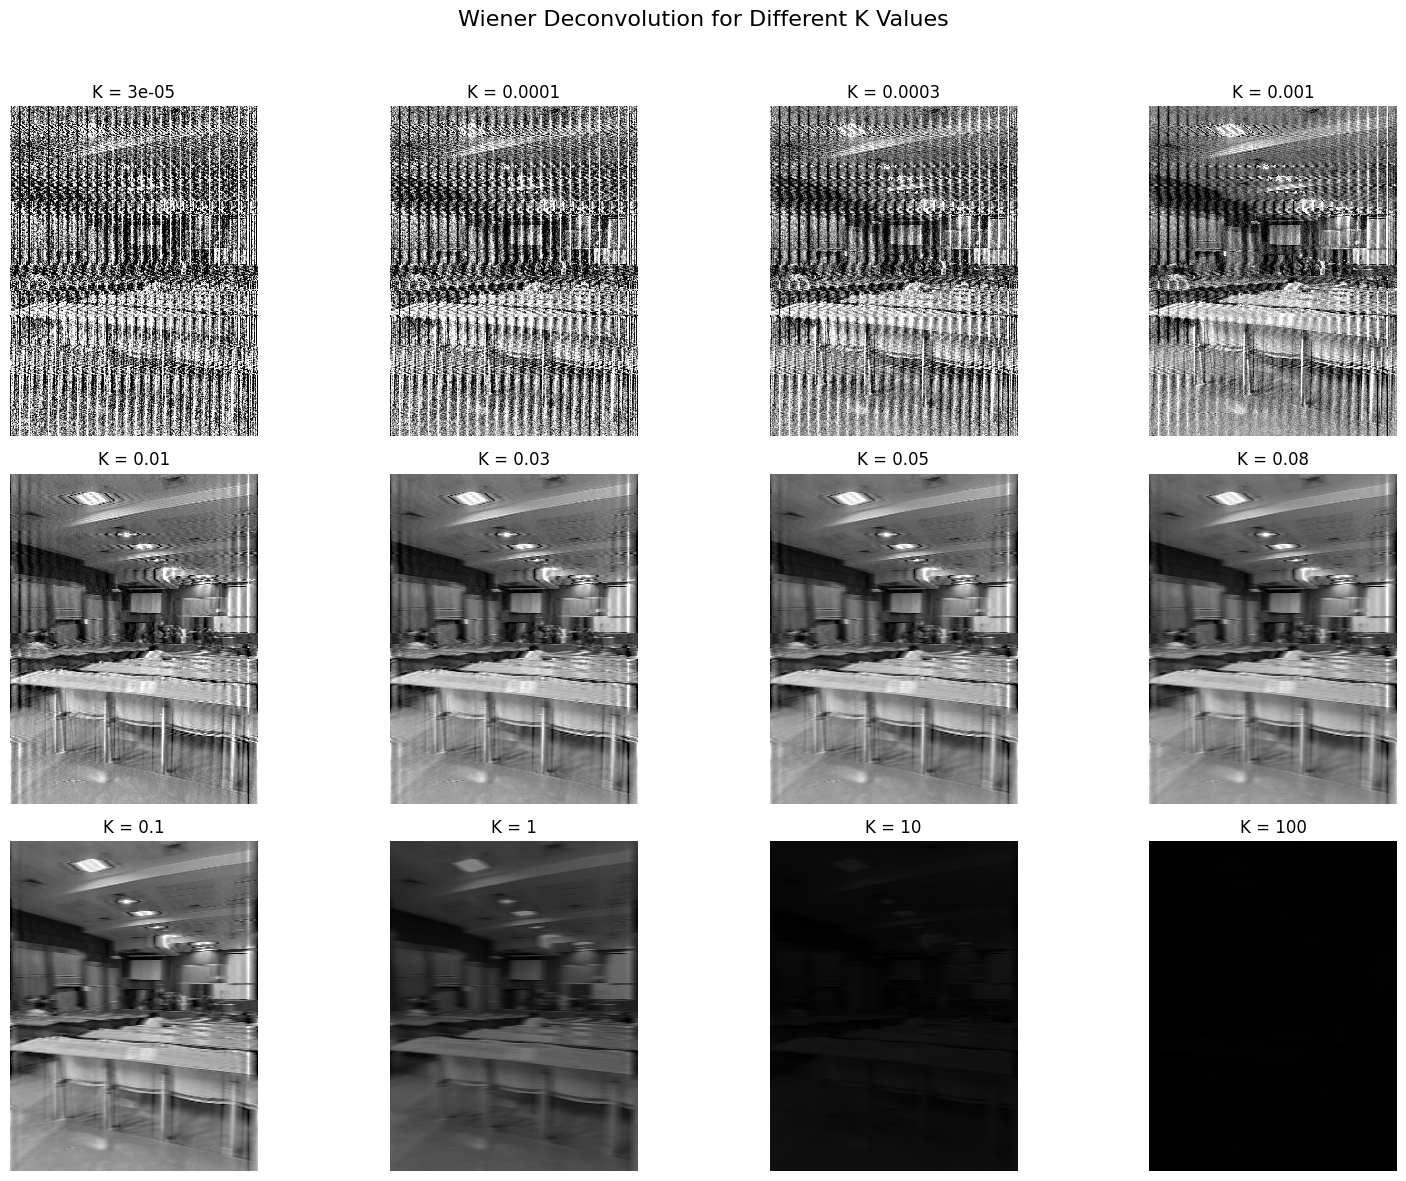

In [106]:
# ---------------------------------------------------------
# TEST DIFFERENT K VALUES - ROBUST VERSION
# ---------------------------------------------------------

K_values = [
    3e-5,
    1e-4,
    3e-4,
    1e-3,
    1e-2,
    3e-2,
    5e-2,
    8e-2,
    1e-1,
    1,
    10,
    100
]

# Create figure
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, K in enumerate(K_values):

    result = wiener_deconvolution(G, H, K)

    axes[i].imshow(
        result,
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest"
    )

    axes[i].set_title(f"K = {K:g}")
    axes[i].axis("off")


# Hide unused subplot
axes[-1].axis("off")

plt.suptitle(
    "Wiener Deconvolution for Different K Values",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

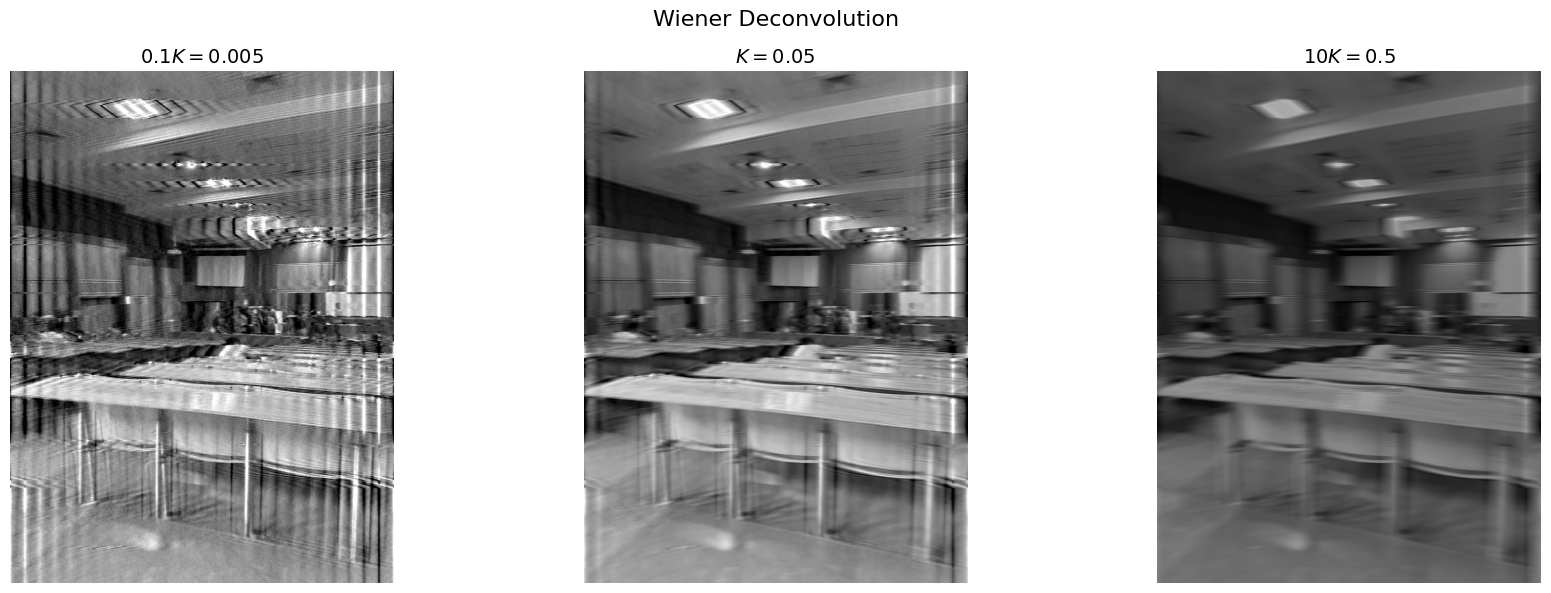

In [107]:
# ---------------------------------------------------------
# REQUIRED WIENER RESULTS
# K_best = 0.03
# ---------------------------------------------------------

K_best = 0.05

K_values_required = [
    0.1 * K_best,
    K_best,
    10 * K_best
]

results = []

for K in K_values_required:

    result = wiener_deconvolution(G, H, K)
    results.append(result)


# ---------------------------------------------------------
# DISPLAY
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = [
    rf"$0.1K = {K_values_required[0]:g}$",
    rf"$K = {K_values_required[1]:g}$",
    rf"$10K = {K_values_required[2]:g}$"
]

for ax, result, title in zip(axes, results, titles):

    ax.imshow(
        result,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.suptitle(
    "Wiener Deconvolution",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [110]:
# ---------------------------------------------------------
# SAVE RESULTS
# ---------------------------------------------------------

os.makedirs("part3_results", exist_ok=True)


def save_image(filename, image):
    image_uint8 = (np.clip(image, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(image_uint8).save(
        "part3_results/" + filename
    )


# Input
save_image("01_input.png", f)

# H magnitude
save_image("02_H_magnitude.png", H_mag_shifted / H_mag_shifted.max())

# Inverse
save_image("03_inverse_filter.png", f_inverse_display)

# Wiener
save_image("04_wiener_0.1K.png", results[0])
save_image("05_wiener_best.png", results[1])
save_image("06_wiener_10K.png", results[2])

# Regularized
save_image("07_regularized_best.png", results[2])

print("Saved results in: part3_results/")

Saved results in: part3_results/


In [111]:
import shutil

shutil.make_archive(
    "part3_results",
    "zip",
    "part3_results"
)

files.download("part3_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>